In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, jaccard_score

from skimage.feature import graycomatrix, graycoprops

IMAGE_FOLDER = "./KTH_TIPS" 
IMAGE   = "photo.jpeg"

RANDOM_STATE = 42

# Загрузка 

In [2]:
def load_image_paths(image_folder):
    image_paths = []
    labels = []
    
    for class_folder in os.listdir(image_folder):
        class_path = os.path.join(image_folder, class_folder)
        if not os.path.isdir(class_path):
            continue
        
        for file in os.listdir(class_path):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(class_path, file))
                labels.append(class_folder)
    
    return image_paths, np.array(labels)

image_paths, labels = load_image_paths(IMAGE_FOLDER)

print(f"Найдено изображений: {len(image_paths)}")
print(f"Классов: {len(np.unique(labels))}")
print("Классы:", np.unique(labels))

Найдено изображений: 810
Классов: 10
Классы: ['aluminium_foil' 'brown_bread' 'corduroy' 'cotton' 'cracker' 'linen'
 'orange_peel' 'sandpaper' 'sponge' 'styrofoam']


# Гистограмма

In [ ]:
def compute_histogram(gray_image, bins=256):
    hist = cv2.calcHist([gray_image], [0], None, [bins], [0, 256]).flatten()
    hist = hist / (hist.sum() + 1e-8)
    
    values = np.arange(bins)
    features = {}

    features['mean'] = np.sum(hist * values)
    
    variance = np.sum(hist * (values - features['mean'])**2)
    features['std'] = np.sqrt(variance)
    
    if features['std'] > 0:
        features['skewness'] = np.sum(hist * ((values - features['mean']) / features['std'])**3)
    else:
        features['skewness'] = 0.0
    
    if features['std'] > 0:
        features['kurtosis'] = np.sum(hist * ((values - features['mean']) / features['std'])**4) - 3
    else:
        features['kurtosis'] = -3.0
    
    non_zero = hist[hist > 0]
    features['entropy'] = -np.sum(non_zero * np.log2(non_zero))
    
    cdf = np.cumsum(hist)
    features['q1'] = np.argmax(cdf >= 0.25)
    features['q2'] = np.argmax(cdf >= 0.5)
    features['q3'] = np.argmax(cdf >= 0.75)
    
    nz_bins = np.where(hist > 0)[0]
    if len(nz_bins) > 0:
        features['min'] = int(nz_bins[0])
        features['max'] = int(nz_bins[-1])
    else:
        features['min'] = 0
        features['max'] = 255
    
    return features, hist


def extract_histogram_features(gray_image, bins=256):
    stats_dict, hist = compute_histogram(gray_image, bins)
    feature_vec = [
        stats_dict['mean'],
        stats_dict['std'],
        stats_dict['skewness'],
        stats_dict['kurtosis'],
        stats_dict['entropy'],
        stats_dict['q1'],
        stats_dict['q2'],
        stats_dict['q3'],
        stats_dict['min'],
        stats_dict['max'],
    ]
    return np.array(feature_vec, dtype=np.float32)

test_img = cv2.imread(image_paths[0], cv2.IMREAD_GRAYSCALE)
feat, hist = compute_histogram(test_img)

print("Пример признаков гистограммы:")
for k, v in feat.items():
    print(f"{k}: {v:.3f}")


Пример признаков гистограммы:
mean: 117.228
std: 14.636
skewness: -0.551
kurtosis: 2.163
entropy: 5.831
q1: 110.000
q2: 119.000
q3: 126.000
min: 34.000
max: 250.000


# Текстурные признаки Laws

In [4]:
def laws_texture_features(image, normalize=True):
    image = image.astype(np.float32)
    
    L5 = np.array([1, 4, 6, 4, 1], np.float32)
    E5 = np.array([-1, -2, 0, 2, 1], np.float32)
    S5 = np.array([-1, 0, 2, 0, -1], np.float32)
    W5 = np.array([-1, 2, 0, -2, 1], np.float32)
    R5 = np.array([1, -4, 6, -4, 1], np.float32)
    
    masks = [L5, E5, S5, W5, R5]
    
    features = []
    
    for i, m1 in enumerate(masks):
        for j, m2 in enumerate(masks):
            kernel = np.outer(m1, m2)
            filtered = cv2.filter2D(image, -1, kernel)
            energy = np.mean(filtered ** 2)
            features.append(energy)
    
    features = np.array(features, dtype=np.float32)
    
    if normalize and features.sum() > 0:
        features = features / features.sum()
    
    return features


laws_test = laws_texture_features(test_img)
print("Размер вектора Laws:", laws_test.shape)
print("Пример первых 5 значений:", laws_test[:5])


Размер вектора Laws: (25,)
Пример первых 5 значений: [9.98197138e-01 3.91120557e-04 1.15808194e-04 1.04819017e-04
 3.34574026e-04]


# Признаки на основе GLCM

In [ ]:
def compute_glcm_features(image, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
    img_reduced = (image // 8).astype(np.uint8)  
    glcm = graycomatrix(
        img_reduced,
        distances=distances,
        angles=angles,
        levels=32,
        symmetric=True,
        normed=True
    )
    
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
    feats = []
    for p in props:
        val = graycoprops(glcm, p).mean()
        feats.append(val)
    return np.array(feats, dtype=np.float32)


glcm_test = compute_glcm_features(test_img)
print("GLCM признаки:", glcm_test)


GLCM признаки: [2.5477567  1.1213304  0.56318766 0.20597441 0.6282997 ]


# Собираем признаки для всех изображений: Histogram, Laws, GLCM

In [6]:
X_hist = []
X_laws = []
X_glcm = []
y = labels.copy()

for i, path in enumerate(image_paths):
    if i % 50 == 0:
        print(f"Обработано {i}/{len(image_paths)} изображений")
    
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)
    
    X_hist.append(extract_histogram_features(img))
    X_laws.append(laws_texture_features(img))
    X_glcm.append(compute_glcm_features(img))

X_hist = np.array(X_hist)
X_laws = np.array(X_laws)
X_glcm = np.array(X_glcm)

print("Формы матриц признаков:")
print("Histogram:", X_hist.shape)
print("Laws:", X_laws.shape)
print("GLCM:", X_glcm.shape)


Обработано 0/810 изображений
Обработано 50/810 изображений
Обработано 100/810 изображений
Обработано 150/810 изображений
Обработано 200/810 изображений
Обработано 250/810 изображений
Обработано 300/810 изображений
Обработано 350/810 изображений
Обработано 400/810 изображений
Обработано 450/810 изображений
Обработано 500/810 изображений
Обработано 550/810 изображений
Обработано 600/810 изображений
Обработано 650/810 изображений
Обработано 700/810 изображений
Обработано 750/810 изображений
Обработано 800/810 изображений
Формы матриц признаков:
Histogram: (810, 10)
Laws: (810, 25)
GLCM: (810, 5)


# Кодируем метки классов в числа

In [7]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

methods = {
    "Histogram": X_hist,
    "Laws": X_laws,
    "GLCM": X_glcm,
}

print("Пример кодировки классов:")
for cls, lab in zip(le.classes_, le.transform(le.classes_)):
    print(cls, "->", lab)


Пример кодировки классов:
aluminium_foil -> 0
brown_bread -> 1
corduroy -> 2
cotton -> 3
cracker -> 4
linen -> 5
orange_peel -> 6
sandpaper -> 7
sponge -> 8
styrofoam -> 9


# Обучение трёх классификаторов для каждого типа признаков

In [ ]:
models = {
    "kNN": KNeighborsClassifier(n_neighbors=3),
    "SVM": SVC(kernel='rbf', random_state=RANDOM_STATE),
    "Tree": DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
}

trained_models = {} 

for method_name, X in methods.items():
    print("\n====", method_name.upper(), "====")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, 
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_encoded
    )
    
    method_models = {}
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    for model_name, model_template in models.items():
        if model_name == "SVM":
            model = SVC(kernel='rbf', random_state=RANDOM_STATE)
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            method_models[model_name] = (model, scaler)
        else:
            model = model_template
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            method_models[model_name] = (model, None)
        
        print(f"\n[{method_name} + {model_name}] accuracy = {accuracy_score(y_test, y_pred):.3f}")
        print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    trained_models[method_name] = method_models

print("\nОбучение завершено.")



==== HISTOGRAM ====

[Histogram + kNN] accuracy = 0.808
                precision    recall  f1-score   support

aluminium_foil       0.95      0.95      0.95        20
   brown_bread       0.86      0.95      0.90        20
      corduroy       0.66      0.95      0.78        20
        cotton       0.59      0.62      0.60        21
       cracker       0.83      0.90      0.86        21
         linen       0.94      0.75      0.83        20
   orange_peel       1.00      0.90      0.95        21
     sandpaper       0.54      0.35      0.42        20
        sponge       0.83      0.75      0.79        20
     styrofoam       0.90      0.95      0.93        20

      accuracy                           0.81       203
     macro avg       0.81      0.81      0.80       203
  weighted avg       0.81      0.81      0.80       203


[Histogram + SVM] accuracy = 0.833
                precision    recall  f1-score   support

aluminium_foil       1.00      1.00      1.00        20
   brow

# Сегментация изображения по патчам на основе классификатора

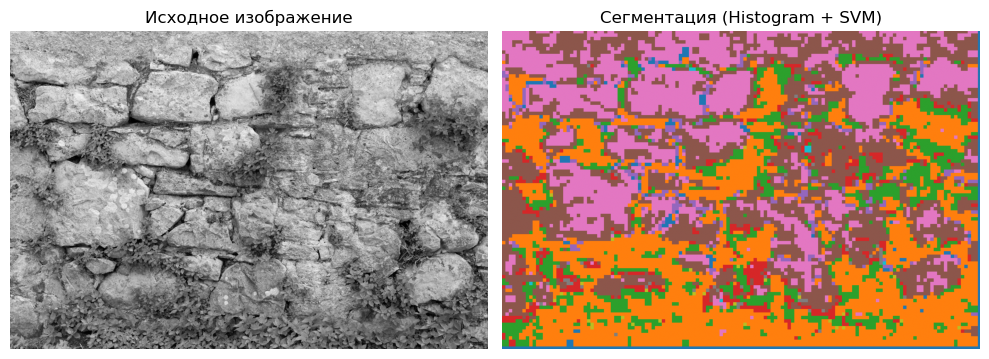

In [ ]:
def extract_features_patch(patch, method_name):
    if method_name == "Histogram":
        return extract_histogram_features(patch)
    elif method_name == "Laws":
        return laws_texture_features(patch)
    elif method_name == "GLCM":
        return compute_glcm_features(patch)
    else:
        raise ValueError("Unknown method:", method_name)


def segment_image(image_path, method_name="Histogram", model_name="SVM",
                  patch_size=16, step=8):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(image_path)
    
    h, w = img.shape
    seg_map = np.zeros((h, w), dtype=np.int32)
    
    model, scaler = trained_models[method_name][model_name]
    
    for y in range(0, h - patch_size + 1, step):
        for x in range(0, w - patch_size + 1, step):
            patch = img[y:y+patch_size, x:x+patch_size]
            feats = extract_features_patch(patch, method_name).reshape(1, -1)
            
            if scaler is not None:
                feats = scaler.transform(feats)
            
            pred = model.predict(feats)[0]
            
            seg_map[y:y+patch_size, x:x+patch_size] = pred
    
    return img, seg_map


orig_img, seg_map_hist_svm = segment_image(
    IMAGE,
    method_name="Histogram",
    model_name="SVM",
    patch_size=16,
    step=8
)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(orig_img, cmap='gray')
plt.title("Исходное изображение")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(seg_map_hist_svm, cmap='tab10')
plt.title("Сегментация (Histogram + SVM)")
plt.axis('off')

plt.tight_layout()
plt.show()


# Чтение ручной маски

Уникальные значения в ручной маске (до): [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 2

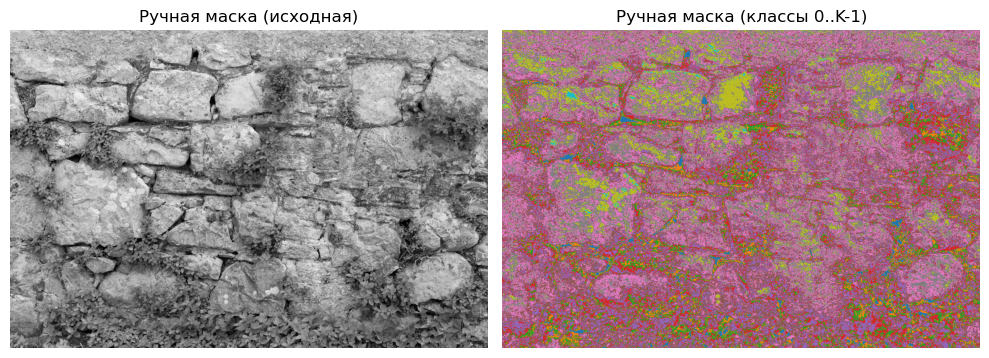

In [10]:
def relabel_mask(mask):
    """Преобразует произвольные значения яркости в классы 0..K-1."""
    values = np.unique(mask)
    mapping = {v: i for i, v in enumerate(values)}
    
    new_mask = np.zeros_like(mask, dtype=np.int32)
    for v, idx in mapping.items():
        new_mask[mask == v] = idx
    return new_mask, mapping

manual_mask_raw = cv2.imread(IMAGE, cv2.IMREAD_GRAYSCALE)
manual_mask, manual_mapping = relabel_mask(manual_mask_raw)

print("Уникальные значения в ручной маске (до):", np.unique(manual_mask_raw))
print("После перекодировки:", np.unique(manual_mask))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(manual_mask_raw, cmap='gray')
plt.title("Ручная маска (исходная)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(manual_mask, cmap='tab10')
plt.title("Ручная маска (классы 0..K-1)")
plt.axis('off')

plt.tight_layout()
plt.show()

# Приведение размеров предсказания к маске

In [11]:
print("Размер оригинального изображения:", orig_img.shape)
print("Размер предсказанной маски:", seg_map_hist_svm.shape)
print("Размер ручной маски:", manual_mask.shape)

if seg_map_hist_svm.shape != manual_mask.shape:
    seg_resized = cv2.resize(seg_map_hist_svm.astype(np.int32),
                             (manual_mask.shape[1], manual_mask.shape[0]),
                             interpolation=cv2.INTER_NEAREST)
else:
    seg_resized = seg_map_hist_svm

print("Размер предсказания после ресайза:", seg_resized.shape)

Размер оригинального изображения: (750, 1125)
Размер предсказанной маски: (750, 1125)
Размер ручной маски: (750, 1125)
Размер предсказания после ресайза: (750, 1125)


# Сопоставление предсказанных классов классам ручной разметки + расчёт метрик

Сопоставление классов предсказания -> разметка: {0: 0, 1: 105, 2: 106, 3: 138, 4: 158, 5: 164, 6: 196, 7: 133, 8: 128, 9: 129}

Pixel accuracy: 0.013
IoU по классам:
  class 0: IoU = 0.009
  class 1: IoU = 0.000
  class 2: IoU = 0.000
  class 3: IoU = 0.000
  class 4: IoU = 0.000
  class 5: IoU = 0.000
  class 6: IoU = 0.000
  class 7: IoU = 0.000
  class 8: IoU = 0.000
  class 9: IoU = 0.000
  class 10: IoU = 0.000
  class 11: IoU = 0.000
  class 12: IoU = 0.000
  class 13: IoU = 0.000
  class 14: IoU = 0.000
  class 15: IoU = 0.000
  class 16: IoU = 0.000
  class 17: IoU = 0.000
  class 18: IoU = 0.000
  class 19: IoU = 0.000
  class 20: IoU = 0.000
  class 21: IoU = 0.000
  class 22: IoU = 0.000
  class 23: IoU = 0.000
  class 24: IoU = 0.000
  class 25: IoU = 0.000
  class 26: IoU = 0.000
  class 27: IoU = 0.000
  class 28: IoU = 0.000
  class 29: IoU = 0.000
  class 30: IoU = 0.000
  class 31: IoU = 0.000
  class 32: IoU = 0.000
  class 33: IoU = 0.000
  class 34: IoU = 0.000
  cl

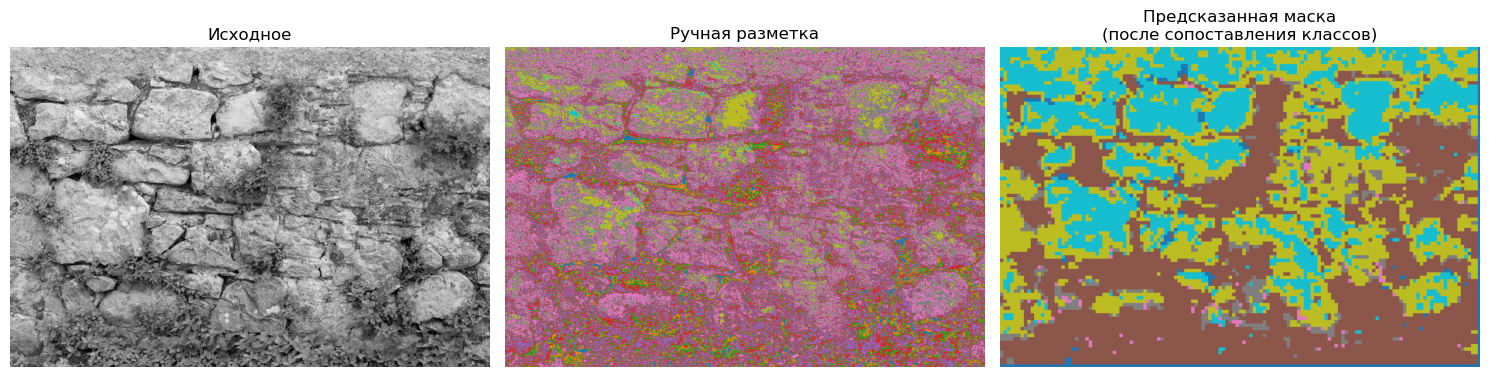

In [ ]:
def match_classes(manual_mask, pred_mask):
    """
    Простое сопоставление классов:
    для каждого предсказанного класса ищем класс разметки, 
    с которым максимальное пересечение.
    """
    manual_classes = np.unique(manual_mask)
    pred_classes = np.unique(pred_mask)
    
    mapping = {}
    used_manual = set()
    
    for pc in pred_classes:
        best_class = None
        best_overlap = -1
        
        for mc in manual_classes:
            if mc in used_manual:
                continue
            overlap = np.logical_and(manual_mask == mc, pred_mask == pc).sum()
            if overlap > best_overlap:
                best_overlap = overlap
                best_class = mc
        
        if best_class is not None:
            mapping[pc] = best_class
            used_manual.add(best_class)
    
    return mapping


def remap_pred_mask(pred_mask, mapping):
    new_pred = np.zeros_like(pred_mask, dtype=np.int32)
    for pc, mc in mapping.items():
        new_pred[pred_mask == pc] = mc
    return new_pred


class_mapping = match_classes(manual_mask, seg_resized)
print("Сопоставление классов предсказания -> разметка:", class_mapping)

seg_mapped = remap_pred_mask(seg_resized, class_mapping)

acc = accuracy_score(manual_mask.flatten(), seg_mapped.flatten())
print(f"\nPixel accuracy: {acc:.3f}")

manual_classes = np.unique(manual_mask)
print("IoU по классам:")
for cls in manual_classes:
    iou = jaccard_score(
        (manual_mask.flatten() == cls).astype(int),
        (seg_mapped.flatten() == cls).astype(int)
    )
    print(f"  class {cls}: IoU = {iou:.3f}")

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(orig_img, cmap='gray')
plt.title("Исходное")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(manual_mask, cmap='tab10')
plt.title("Ручная разметка")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(seg_mapped, cmap='tab10')
plt.title("Предсказанная маска\n(после сопоставления классов)")
plt.axis('off')

plt.tight_layout()
plt.show()